# Permit Complexity Exploration

Author: Lauren Connelly and Team Red (Margaret Keu, Florian Ewing, John Farnandez)

In this notebook we will conduct a preliminary exploration into what makes a permit complex. This will be done through visualization of relationships between features and the target variable (totaldaysplanreview) and calculation of correlation coefficients to establish which features may play a role in the complexity of the approval process for permits. 

In [1]:
# Import necessary libraries for analysis

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Set option to view all columns

pd.set_option('display.max_columns', None)

In [4]:
# Load dataset

permit_df = pd.read_csv('output/master_dataset.csv')
permit_df.head()

,permitnum,originaladdress1,latitude,longitude,totaldaysplanreview,log_target,permittypedesc,dwellingunittype,housingcategory,zone_family,zoning,estprojectcost,log_estprojectcost,housingunitsadded,log_housingunitsadded,dependentbuilding,app_year,app_month,app_quarter,has_rejection,total_review_cycles,n_correction_cycles,any_corrections_required,n_reviewers_assigned,n_review_types,review_types_list,review_complexity_max,has_comments,n_comments,n_distinct_comment_subjects,comment_reviewcycle_max,daysplanreviewcity,daysinitialplanreview,daysoutcorrections,numberreviewcycles,daysissuepermitcity,permitclass,permitclassmapped,permittypemapped,statuscurrent,housingunits,housingunitsremoved,applieddate,issueddate,completeddate
0,6421136-CN,8636 45TH AVE NE,47.691545,-122.279752,657.0,6.489205,Addition/Alteration,Accessory Dwelling Attached,Middle Housing,NR,NR2,100000.0,11.512935,1.0,0.693147,0,2021,2,1,True,3,5,True,8,6,Addressing|ECA GeoTech|Energy|Ordinance/Struct...,Full +,False,0,0,0.0,64.0,26.0,593.0,3.0,65.0,Single Family/Duplex,Residential,Building,Completed,1.0,0.0,2021-02-17,2022-12-07,2024-03-11
1,6568195-CN,14370 EDGEWATER LN NE,47.733667,-122.284293,63.0,4.158883,Addition/Alteration,Single Family/Duplex,Single-Family Add/Alt,SF,SF 5000,100000.0,11.512935,0.0,0.000000,0,2020,3,1,True,3,5,True,8,8,Addressing|ECA GeoTech|Energy|Ordinance|Shorel...,Full C,False,0,0,0.0,53.0,31.0,10.0,3.0,53.0,Single Family/Duplex,Residential,Building,Completed,0.0,0.0,2020-03-03,2020-05-05,2021-09-13
2,6577733-CN,1729 NE 88TH ST,47.691975,-122.308374,177.0,5.181784,Addition/Alteration,Single Family/Duplex,Single-Family Add/Alt,SF,SF 5000,10000.0,9.210440,0.0,0.000000,0,2020,11,4,True,3,4,True,5,5,Addressing|Geo Soils|Ordinance/Structural|Side...,Full,False,0,0,0.0,117.0,29.0,60.0,3.0,117.0,Single Family/Duplex,Residential,Building,Completed,0.0,0.0,2020-11-04,2021-04-30,2022-02-04
3,6508850-CN,11735 4TH AVE NW,47.715108,-122.363018,402.0,5.998937,New,Detached Single-Family,Middle Housing,NR,NR2,499458.0,13.121281,1.0,0.693147,0,2021,10,4,True,4,15,True,11,9,Addressing|Drainage|ECA GeoTech|ECA Riparian|E...,Full +,False,0,0,0.0,161.0,62.0,241.0,4.0,167.0,Single Family/Duplex,Residential,Building,Completed,1.0,0.0,2021-10-05,2022-11-17,2024-01-03
4,6608862-CN,4566 22ND AVE SW,47.561761,-122.361103,1085.0,6.990257,New,Detached Single-Family,Middle Housing,SF,SF 5000,410595.0,12.925365,1.0,0.693147,0,2021,3,1,True,6,20,True,11,8,Addressing|Drainage|ECA GeoTech|Energy|Land Us...,Full C,False,0,0,0.0,299.0,138.0,786.0,6.0,299.0,Single Family/Duplex,Residential,Building,Completed,1.0,0.0,2021-03-10,2024-02-28,2025-07-08


### Numeric Features: Correlation

For numerical columns we will calculate the correlation coefficient between each numerical column and the target, totaldaysplanreview. A high correlation is suggestive that that feature may contribute to permit complexity.

In [5]:
# Isolate numerical columns that can be used to calculate correlation coefficients

num_cols = permit_df[
    ['estprojectcost', 
     'housingunitsadded',
     'total_review_cycles', 
     'n_correction_cycles', 
     'n_reviewers_assigned', 
     'n_review_types',
     'n_comments',
     'daysplanreviewcity',
     'daysinitialplanreview',
     'daysoutcorrections',
     'numberreviewcycles',
     'daysissuepermitcity',
     'housingunits',
     'housingunitsremoved']]

num_cols.head()

,estprojectcost,housingunitsadded,total_review_cycles,n_correction_cycles,n_reviewers_assigned,n_review_types,n_comments,daysplanreviewcity,daysinitialplanreview,daysoutcorrections,numberreviewcycles,daysissuepermitcity,housingunits,housingunitsremoved
0,100000.0,1.0,3,5,8,6,0,64.0,26.0,593.0,3.0,65.0,1.0,0.0
1,100000.0,0.0,3,5,8,8,0,53.0,31.0,10.0,3.0,53.0,0.0,0.0
2,10000.0,0.0,3,4,5,5,0,117.0,29.0,60.0,3.0,117.0,0.0,0.0
3,499458.0,1.0,4,15,11,9,0,161.0,62.0,241.0,4.0,167.0,1.0,0.0
4,410595.0,1.0,6,20,11,8,0,299.0,138.0,786.0,6.0,299.0,1.0,0.0


In [25]:
# Calculate correlation coefficients

target = permit_df['totaldaysplanreview']

correlations = num_cols.corrwith(target).sort_values()
print(correlations)

housingunitsremoved     -0.003478
n_comments               0.124454
estprojectcost           0.135929
n_review_types           0.171045
n_reviewers_assigned     0.263202
housingunitsadded        0.284013
housingunits             0.284677
numberreviewcycles       0.343216
total_review_cycles      0.344643
n_correction_cycles      0.468392
daysinitialplanreview    0.488201
daysoutcorrections       0.525132
daysissuepermitcity      0.622797
daysplanreviewcity       0.712847
dtype: float64


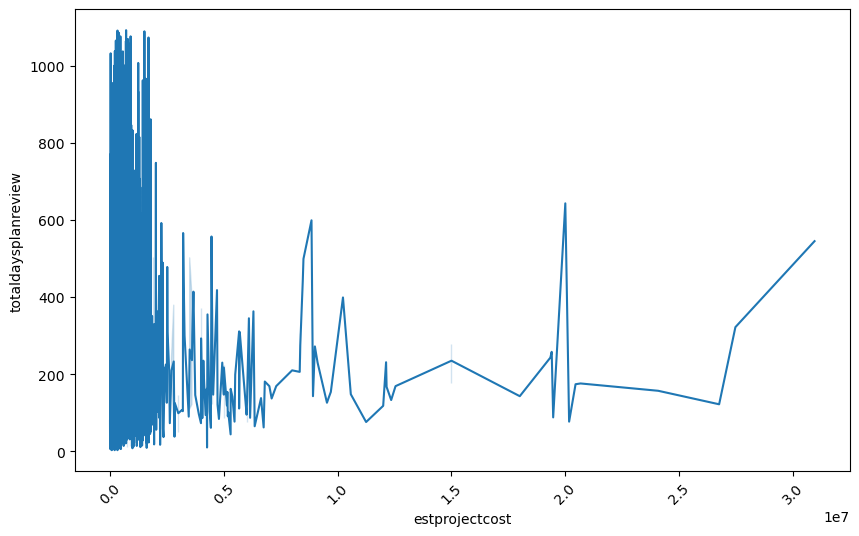

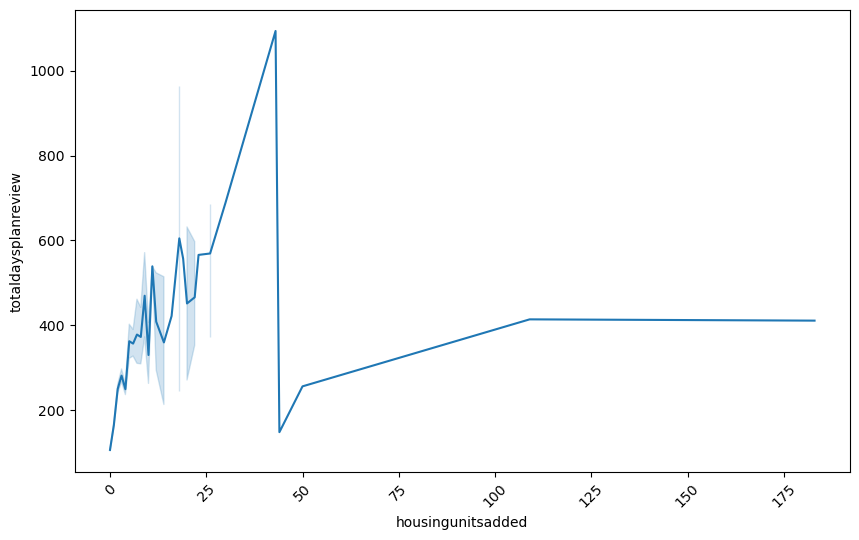

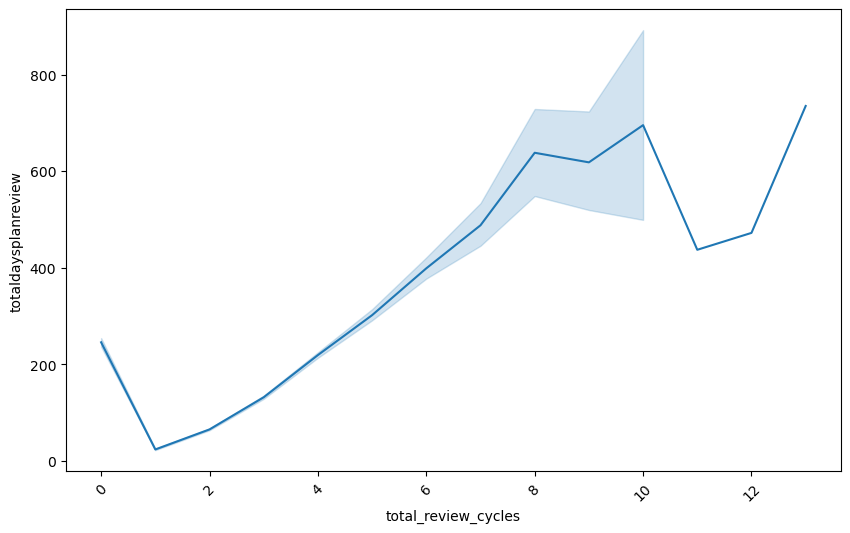

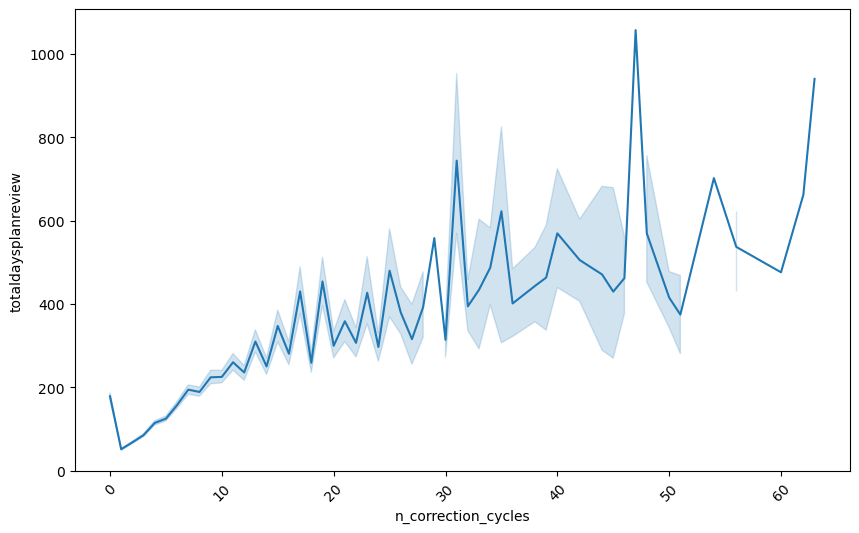

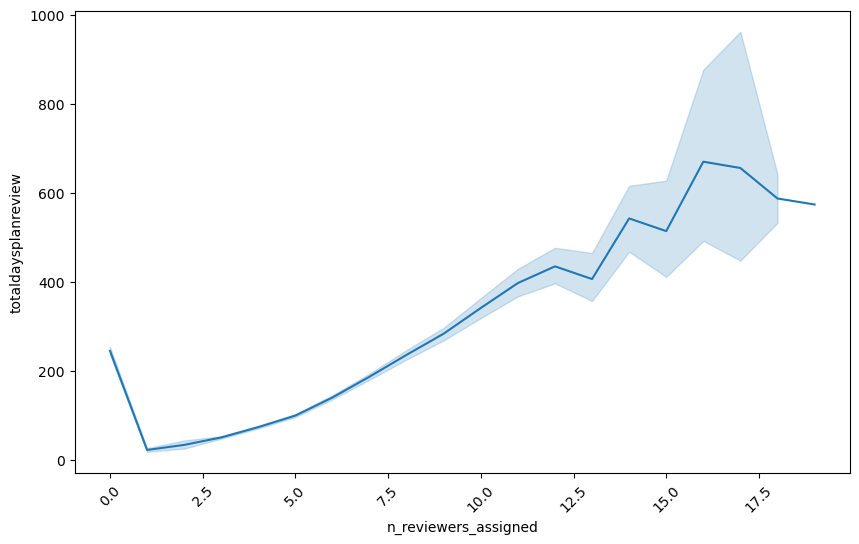

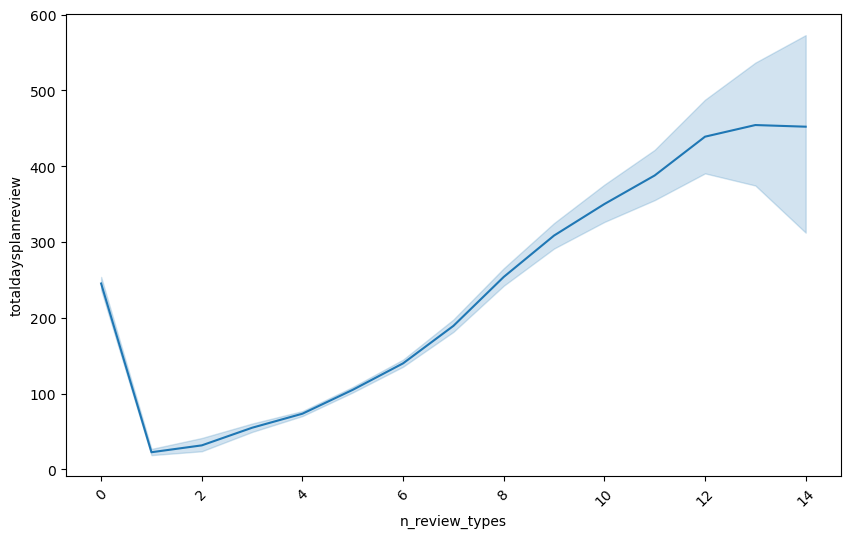

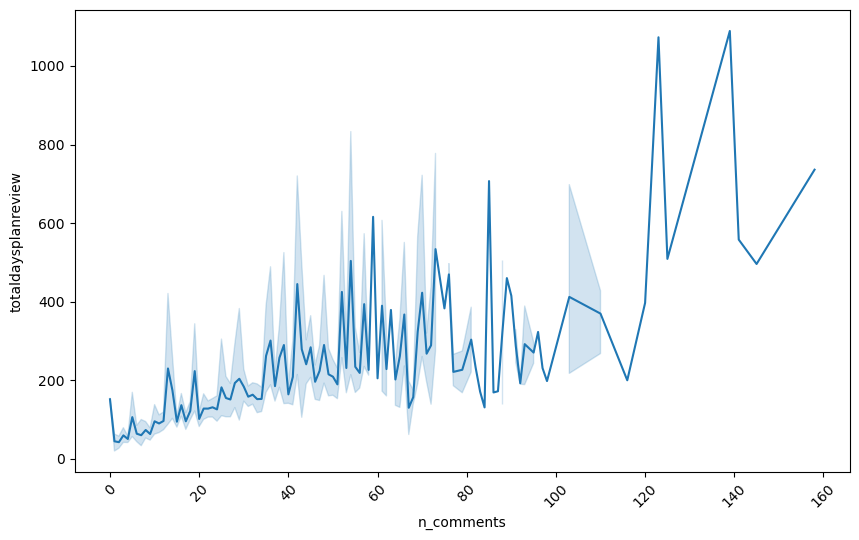

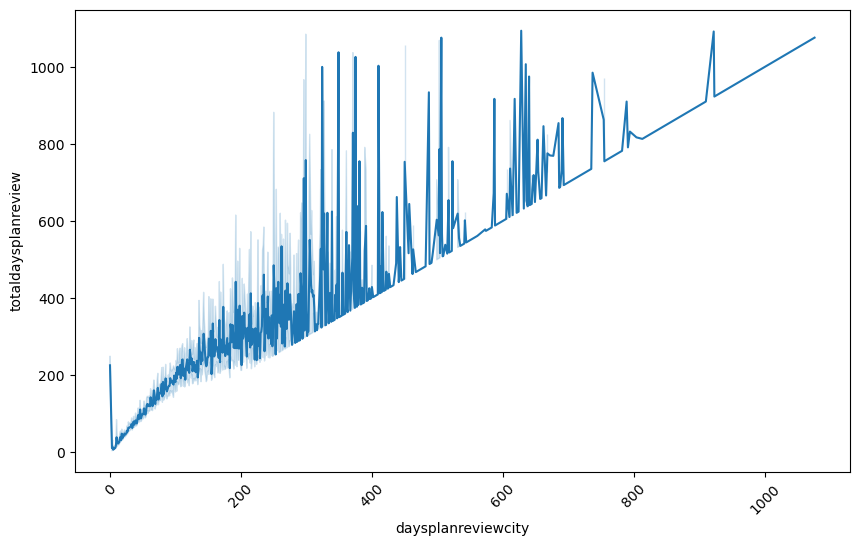

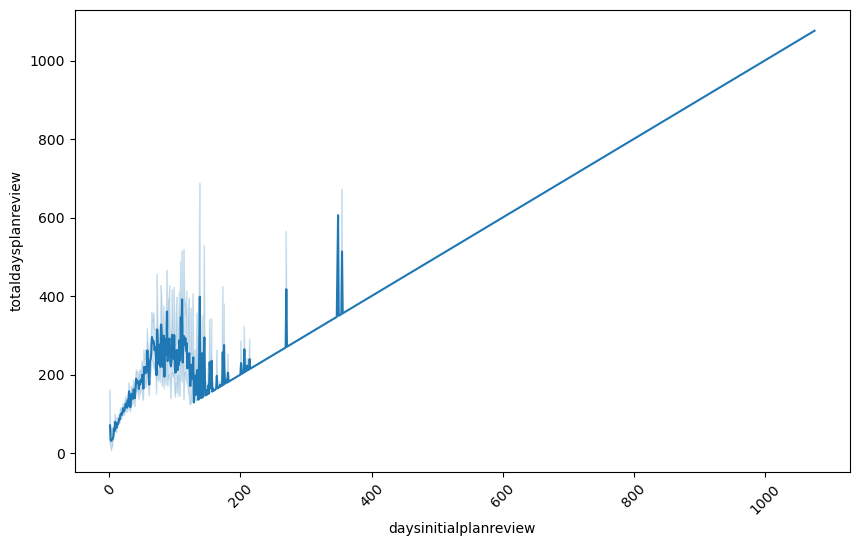

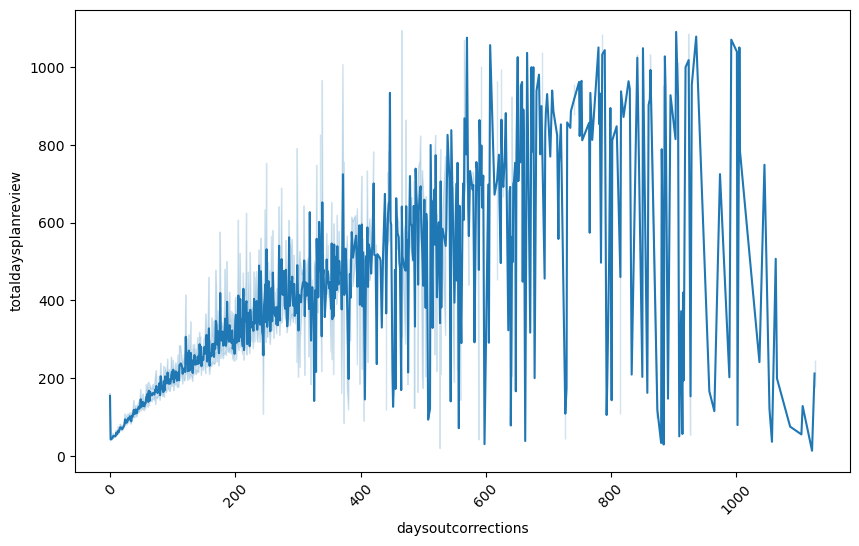

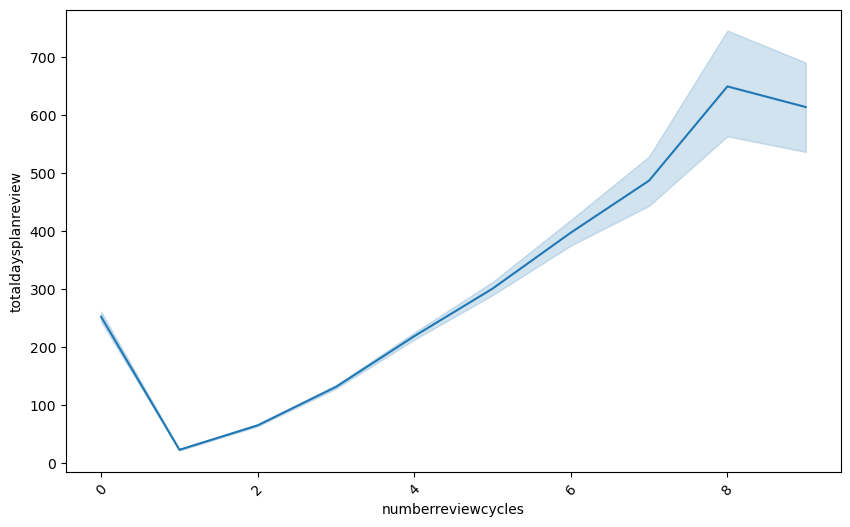

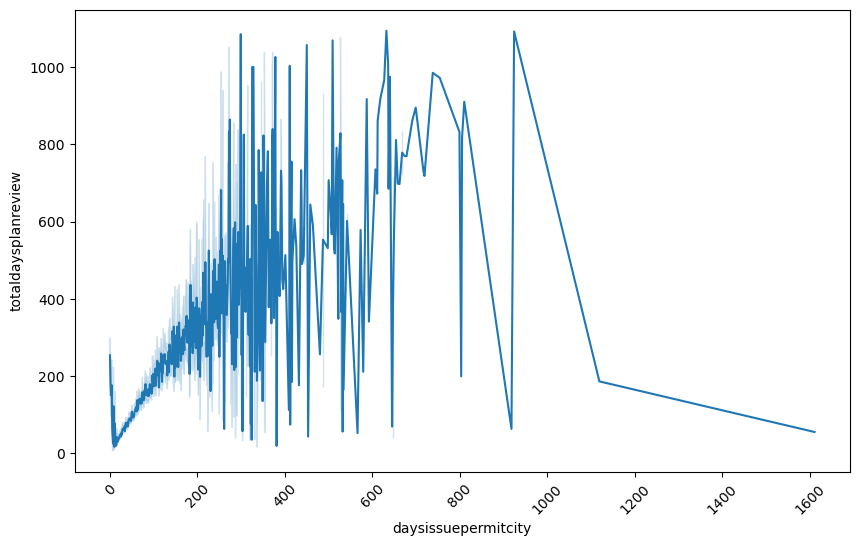

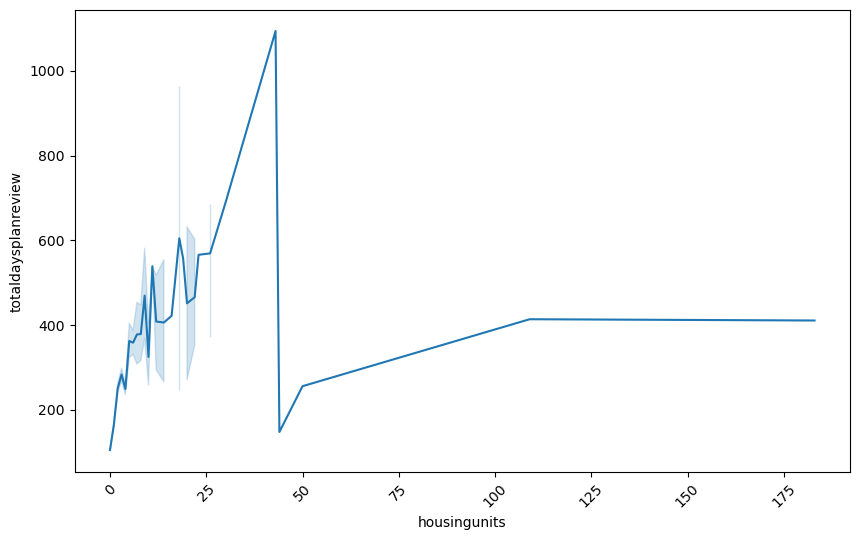

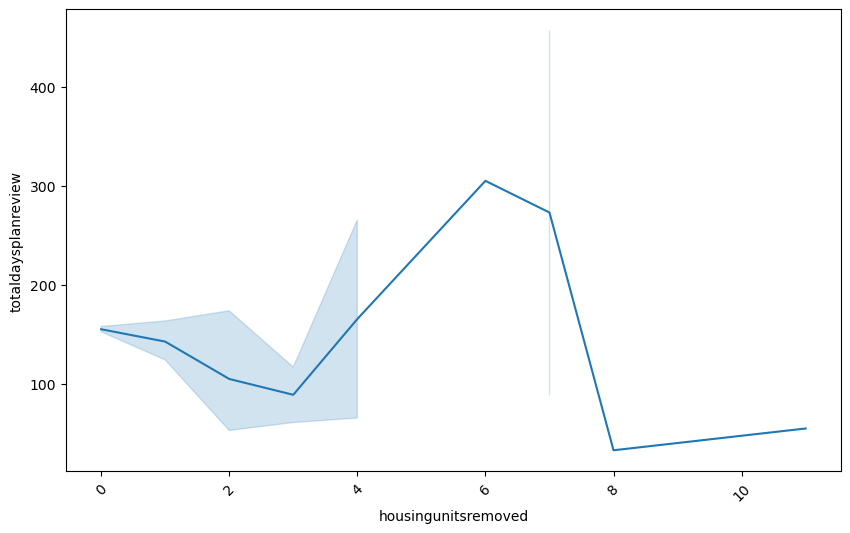

In [37]:
# Visualize relationship between numeric features from above and target (totaldaysplanreview)

for col in num_cols:
    plt.figure(figsize=(10, 6)) 
    sns.lineplot(data=permit_df, x=col, y=permit_df['totaldaysplanreview'])
    plt.xticks(rotation=45)
    plt.show()

The highest correlations here are among the features we would expect: the number of days a permit is in plan review or how long it took to issue the permit, since the sum of those values is totaldaysplanreview. Ignoring those features, the highest correlations are regarding correction cycles and review cycles. There is also a very slight correlation with housing units added. 

### Categorical Features: Association

For categorical features, a correlation coefficient cannot be calculated. We will instead look for association. To do this, we group each feature by category and then calculate the mean of totaldaysplanreview for each category. We are looking for categories that have large values in the mean column because the larger the value in totaldaysplanreview, the more complex the permit is. 

In [ ]:
# Isolate categorical columns. Do not include columns with many unique values such as permit number.
# Omit zoning column, because it has 286 categories which would be difficult to visualize and interpret.

cat_cols = permit_df[
    ['permittypedesc',
     'dwellingunittype',
     'housingcategory',
     'zone_family',
     'dependentbuilding',
     'app_year',
     'app_month',
     'app_quarter',
     'has_rejection',
     'any_corrections_required',
     'review_complexity_max',
     'has_comments',
     'permitclass',
     'permitclassmapped',
     'permittypemapped',
     'statuscurrent']]

In [ ]:
# Create df of the categorical columns along with target totaldaysplanreview in order to do the groupby

cat_cols_target = permit_df[[
    'permittypedesc',
     'dwellingunittype',
     'housingcategory',
     'zone_family',
     'dependentbuilding',
     'app_year',
     'app_month',
     'app_quarter',
     'has_rejection',
     'any_corrections_required',
     'review_complexity_max',
     'has_comments',
     'permitclass',
     'permitclassmapped',
     'permittypemapped',
     'statuscurrent',
     'totaldaysplanreview']]

# Perform groupby for each categorical feature selected and print results

for col in cat_cols:
    means = cat_cols_target.groupby(col)['totaldaysplanreview'].mean().sort_values()
    print(means)
    print('\n')

permittypedesc
Deconstruction                           23.000000
Demolition                               81.810811
Addition/Alteration                     110.226512
Change of Use Only - No Construction    112.074074
New                                     264.171797
Name: totaldaysplanreview, dtype: float64


dwellingunittype
Accessory Dwelling Attached, Small Efficiency Dwelling                               65.000000
Detached Single-Family, Accessory Dwelling Detached                                  87.000000
Commercial                                                                           92.735082
Accessory Dwelling Detached, Accessory Dwelling Attached                            105.000000
Accessory Dwelling Attached                                                         119.805136
Single Family/Duplex                                                                121.278676
Accessory Dwelling Detached, Townhouse                                              136.500000
Acce

In order to interpret this, we also need to know if there is class imbalance for each feature. Excessive class imbalance throws off the mean, so for features that have heavy class imbalance, we cannot rely on the mean as indicative of association.

In [26]:
# Get value counts of each category. Excessive class imbalance changes interpretation of above statistics because it affects the mean.

for col in cat_cols:
    print(cat_cols[col].value_counts().sort_values(), '\n')

permittypedesc
Deconstruction                              1
Change of Use Only - No Construction       27
Demolition                                 37
New                                      4028
Addition/Alteration                     10101
Name: count, dtype: int64 

dwellingunittype
Detached Single-Family, Accessory Dwelling Detached                                    1
Accessory Dwelling Attached, Small Efficiency Dwelling                                 1
Accessory Dwelling Detached, Accessory Dwelling Attached                               1
Cottage                                                                                1
Rowhouse, Townhouse                                                                    1
Accessory Dwelling Detached, Rowhouse                                                  1
Townhouse, Accessory Dwelling Attached                                                 1
Accessory Dwelling Detached, Townhouse                                                 

Based on the above value counts, the following features have useful groupby data:
- permittypedesc (but only among the top two categories)
- dwellingunittype
- housingcategory
- zone_family
- app_year
- app_month
- app_quarter 
- review_complexity_max
- permitclass
- permitclassmapped

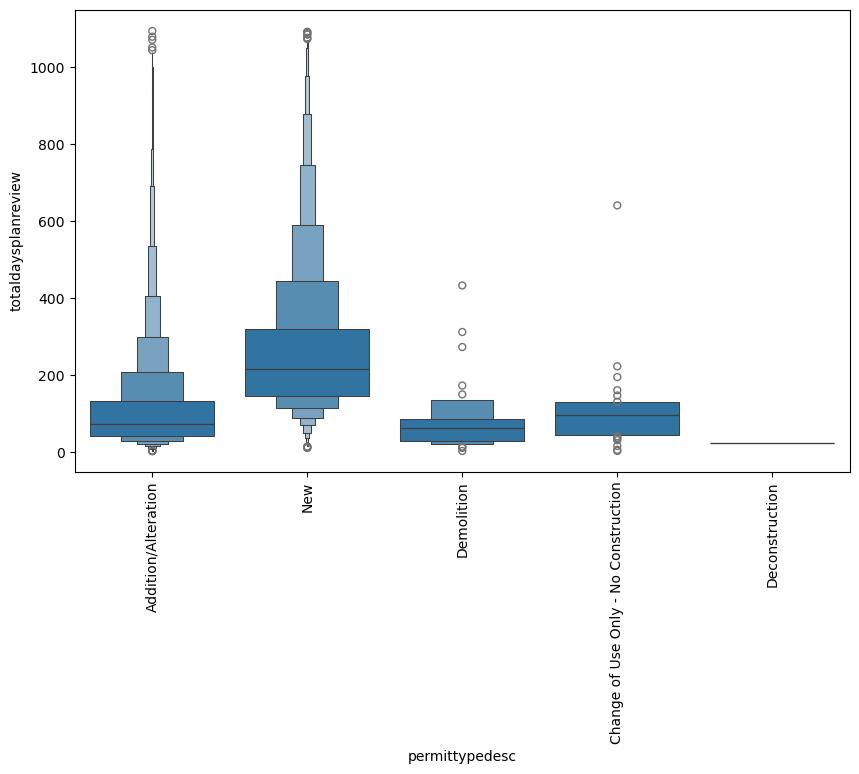

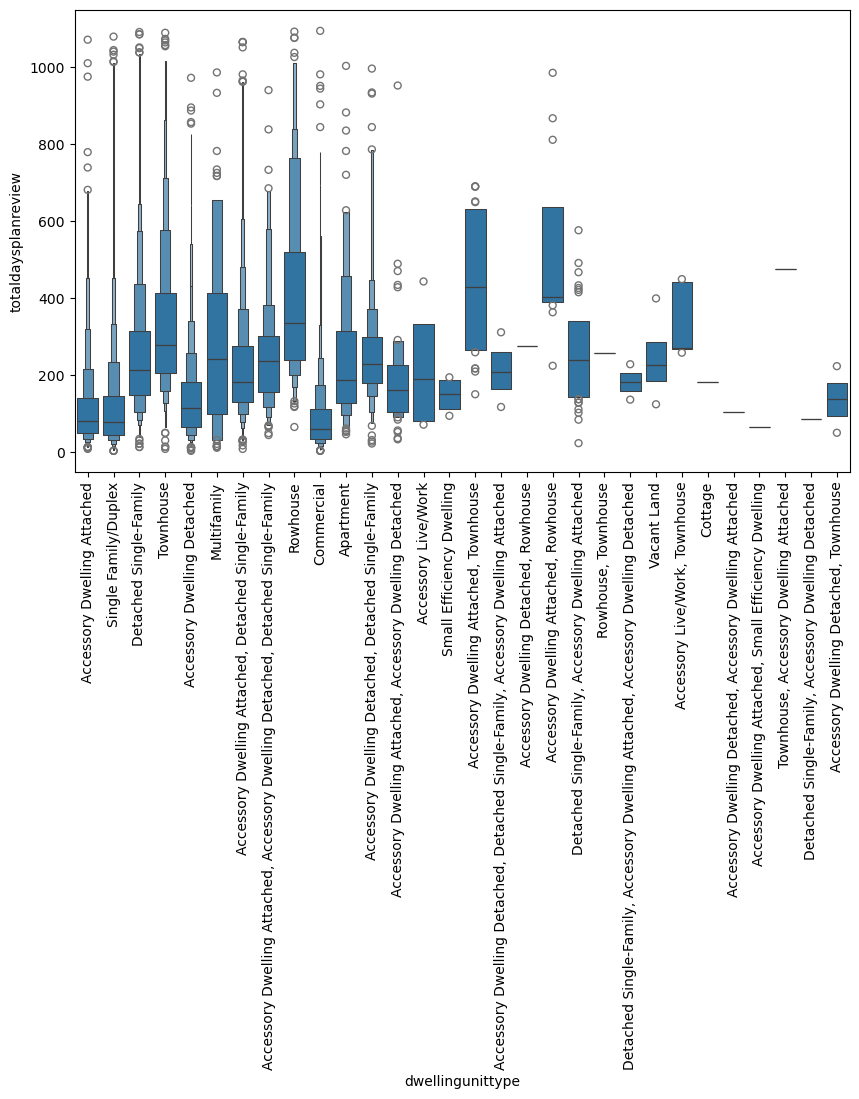

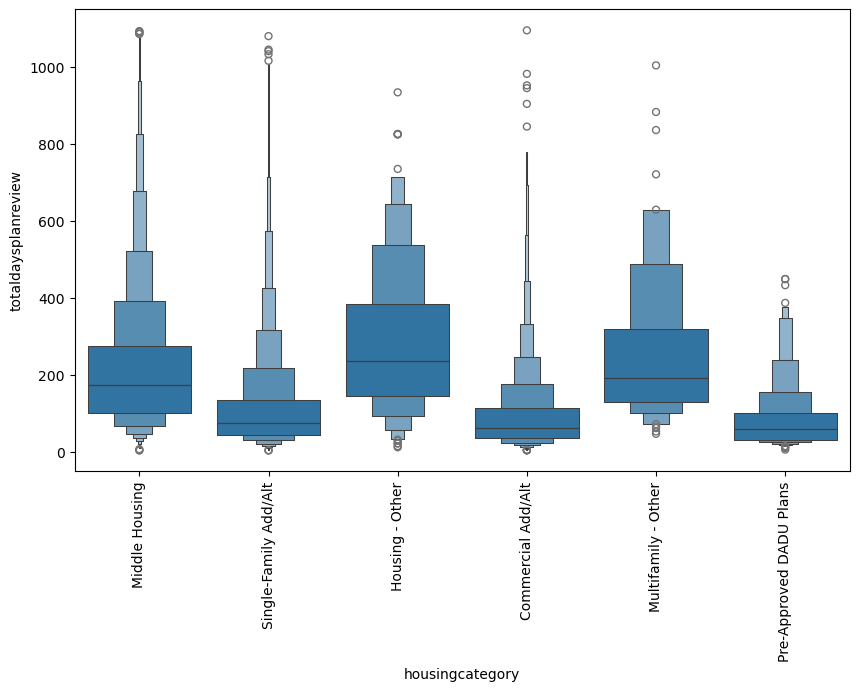

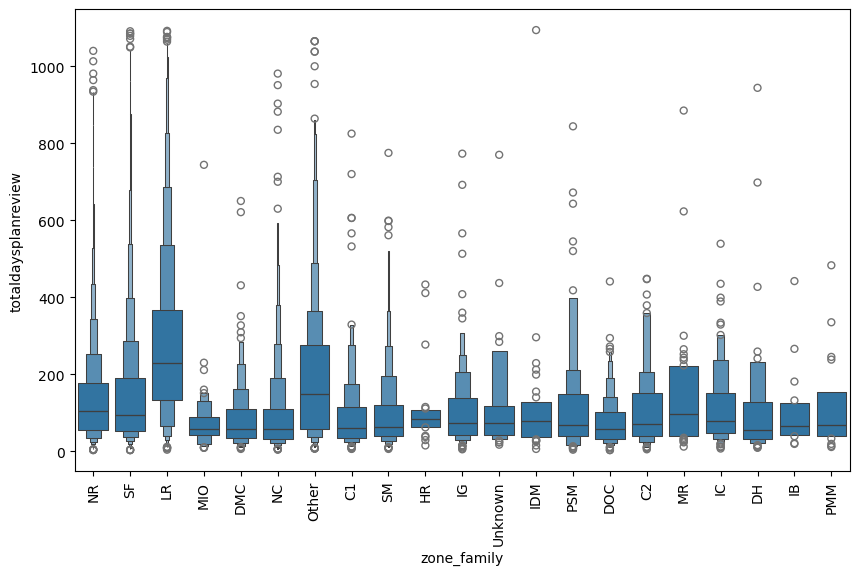

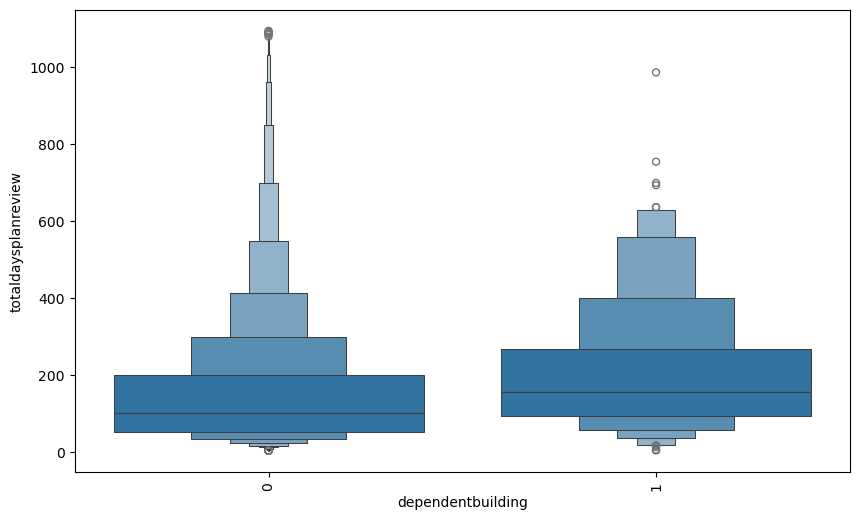

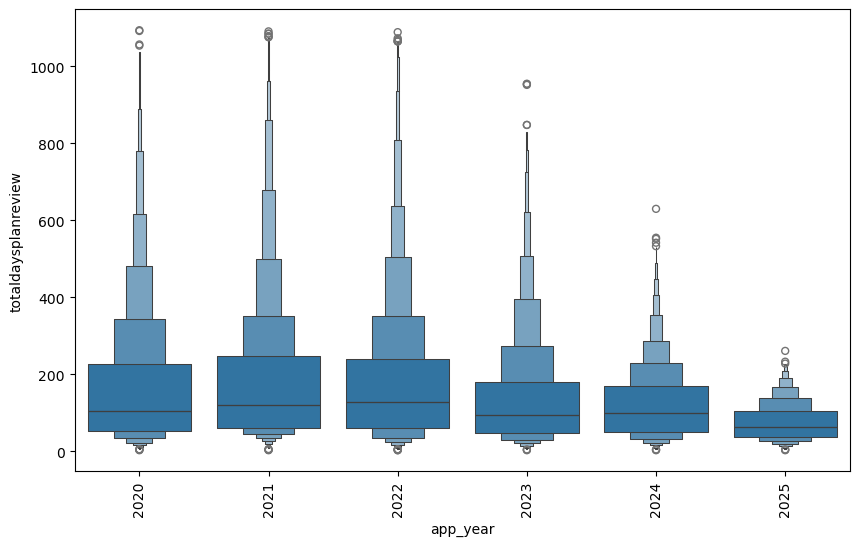

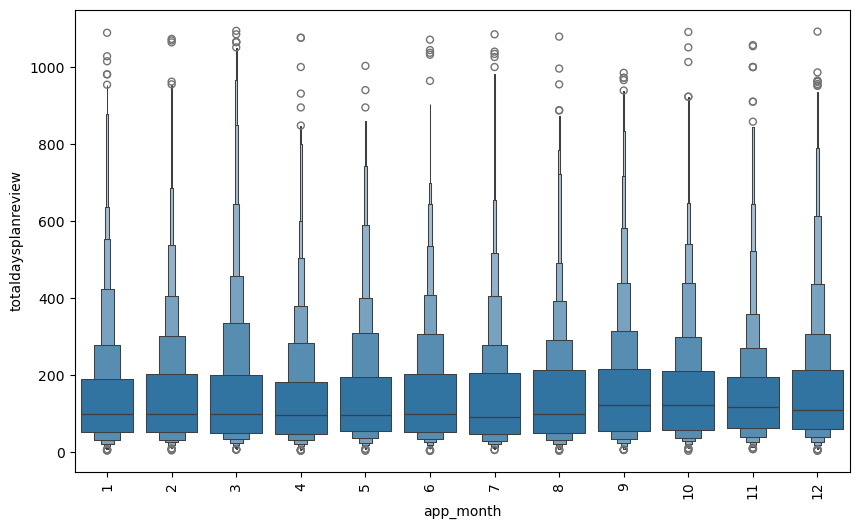

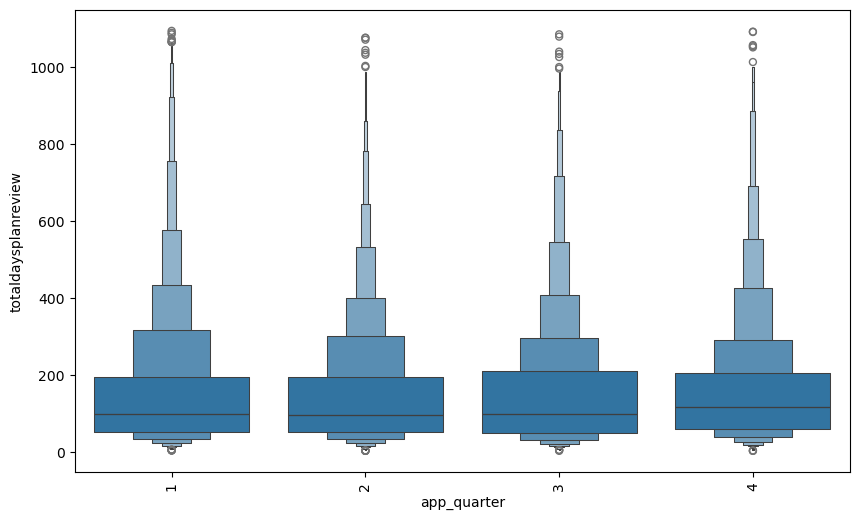

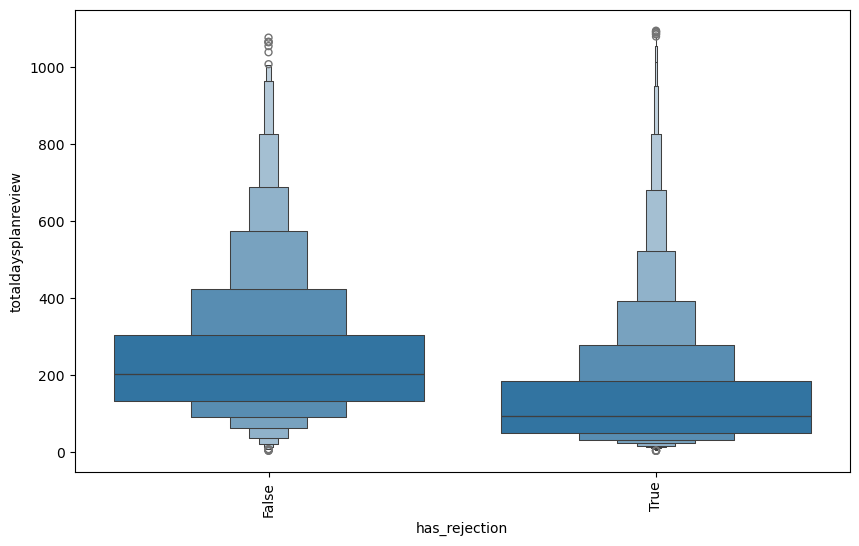

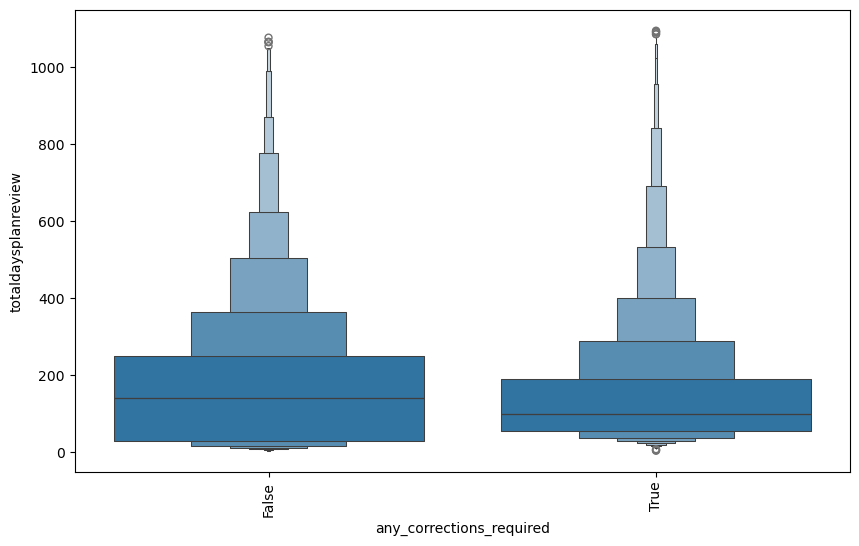

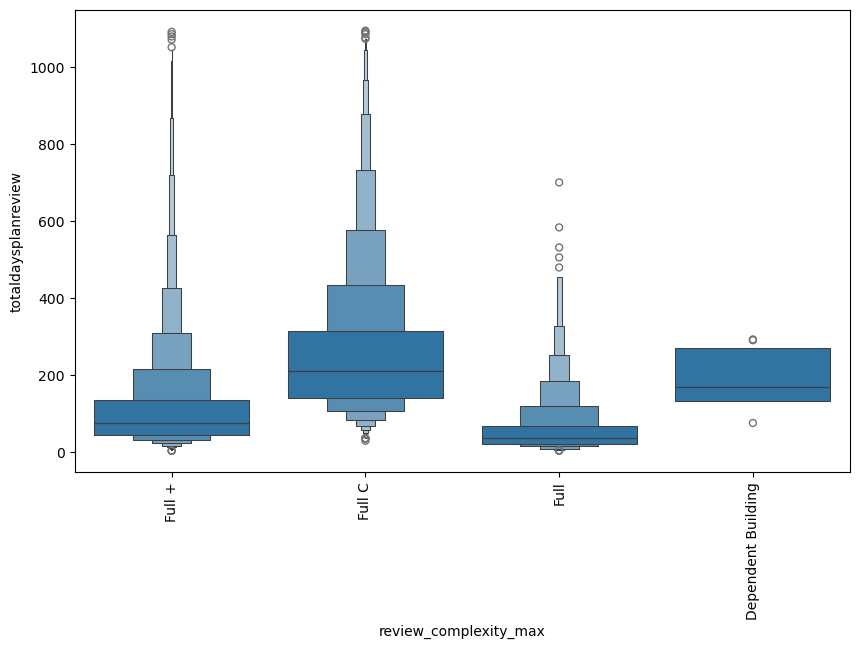

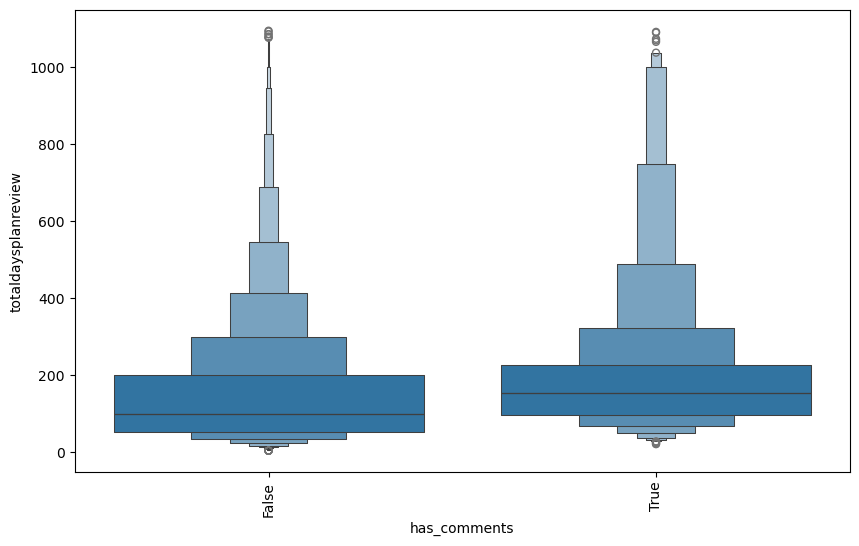

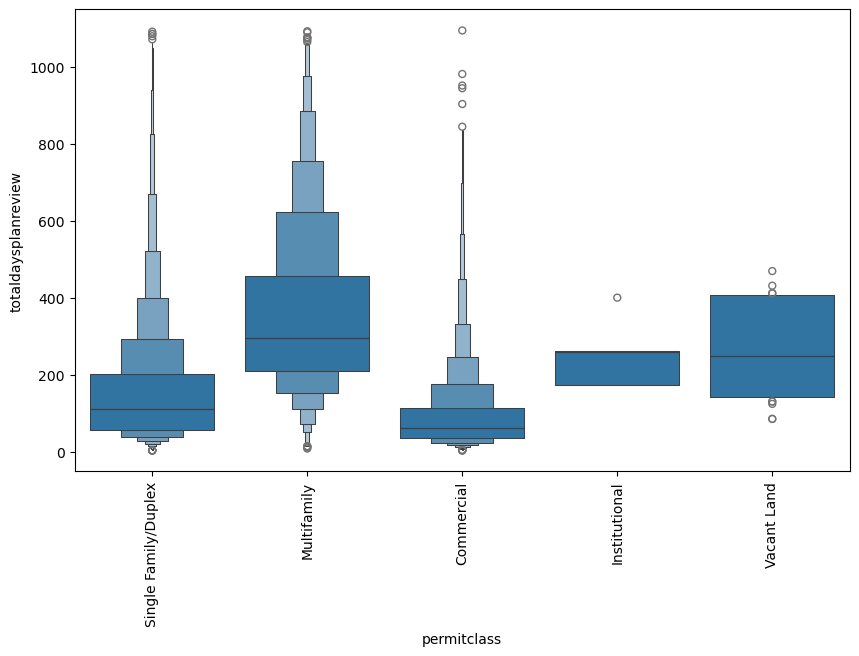

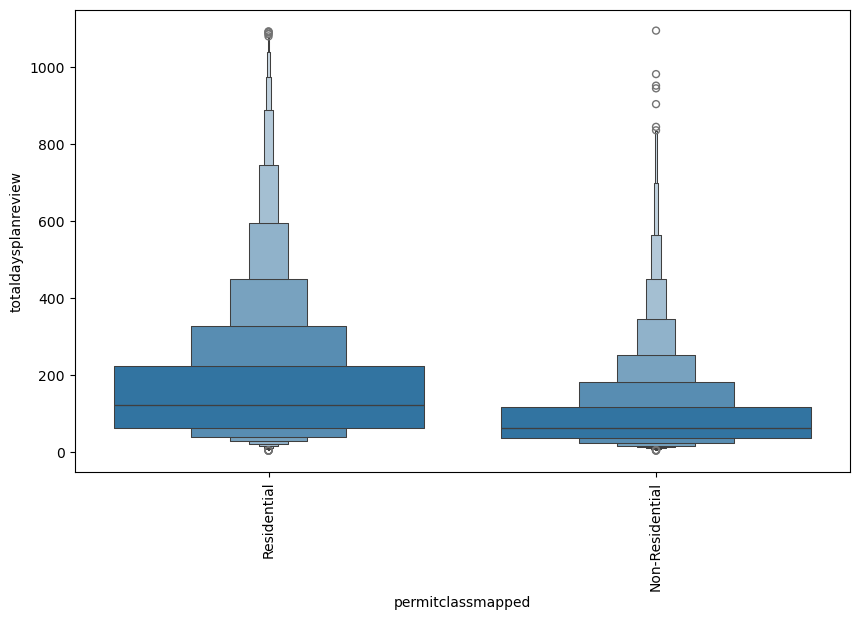

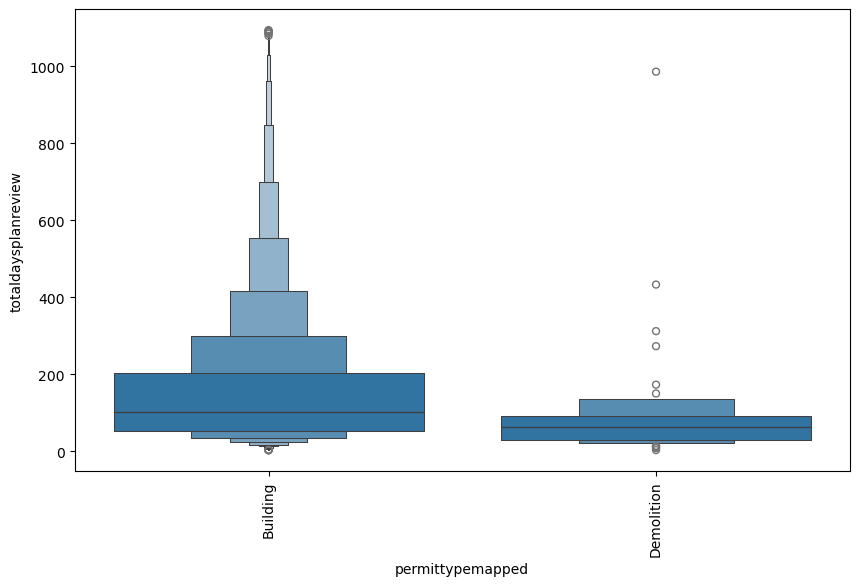

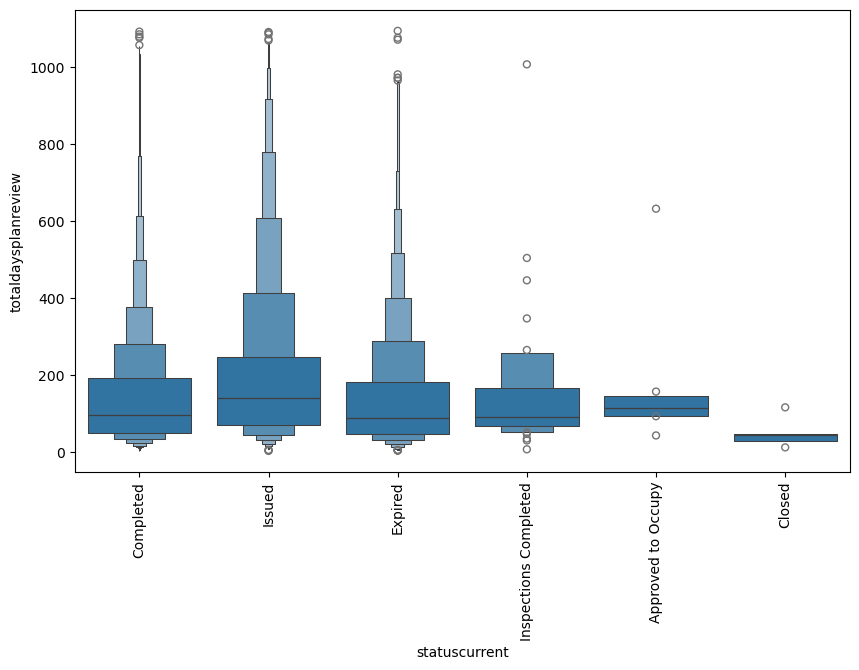

In [27]:
# Visualize relationship between categorical features and target (totaldaysplanreview)

for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.boxenplot(data=permit_df, x=col, y='totaldaysplanreview')
    plt.xticks(rotation=90)
    plt.show()

### Analysis

After removing the features that directly make up the target (e.g. daysinitialplanreview), the features most correlated with the target are housing units added (0.284), housing units (0.285), number of review cycles (0.343), total review cycles (0.345), and number of correction cycles (0.468). Other positive but weaker correlations include estimated project cost (0.136). Permits that require multiple review cycles also have larger values for total days in plan review but we would need to discover the root cause of why those permits require multiple review cycles in the first place.

The categorical features that appear to be most associated with the target are new construction permits (permittype 'new'), housing category ('middle housing'), zone family (SF, NR and LR), review complexity ('full C') and dwelling unit type. Due to the class imbalance in the dwelling unit type feature it is difficult to say which type of dwelling unit is likely to result in permit complexity since there are inverse relationships between the number of data points in each class and the mean of total days in plan review.

### Conclusion and Next Steps

Conclusion:

There are many factors that go into permit complexity. A few that are readily identified are new construction permits, 'middle housing' permits, permits in SF, NR and LR zone families, and potentially permits that have a high estimated project cost. 

Potential Future Areas For Analysis:
- Region: There may be a way to use latitude and longitude data to explore correlation between certain areas of the city and complexity for permits.
- Dwelling unit type: A closer look at the most common dwelling unit types to see if there are associations with permit complexity.